# 03 · Optimization of the PM interval
Find the PM interval that best trades off annual maintenance cost against probability of failure.
- Input: `data/weibull_params.json` (from notebook 02)
- Output: the Pareto front and the recommended PM plan

## Problem formulation
The decision variable is the PM interval $x$ in months, with $1 \le x \le 12$. Both objectives are minimized:

$$
\min\; C(x) = \underbrace{\frac{12}{x}\, C_{PM}\, n}_{\text{preventive}} \;+\; \underbrace{F(x)\, C_{CM}\, n}_{\text{corrective}}
\qquad\qquad
\min\; F(x) = 1 - e^{-(x/\eta)^{\beta}}
$$

- $n$: number of pumps
- $C_{PM}$ = 1: cost of one PM job (costs are in relative units)
- $C_{CM}$ ≈ 125.66: average cost of one corrective job, relative to a PM job
- $F(x)$: probability that a pump fails within one PM interval

Shorter intervals lower the failure risk but add PM jobs, which is the trade-off to optimize. Annual cost is reported as an index, with the current 6-month plan = 100.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pm_optimization as pm

# Same colours and figure style as notebook 02
TEAL, GREY, RED = "#00534d", "#9AA5B1", "#C0392B"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

# Build the cost / failure model from the Weibull fit saved by notebook 02
params = pm.load_params()
model = pm.PMModel.from_params(params)
model

PMModel(beta=1.1465773914889534, eta_months=49.54594188958013, n_pumps=99, pm_cost=1.0, cm_cost=125.6611491829204)

## The current plan and some alternatives
The pumps are currently serviced every 6 months. Both objectives for a few round intervals:

In [2]:
# Whole-month intervals from monthly to yearly, including the current 6 months
intervals = [1, 2, 3, 4, 6, 9, 12]
pd.DataFrame({
    "Annual cost (index)": model.cost_index(intervals).round(1),
    "Failure probability (%)": (model.failure_prob(intervals) * 100).round(2),
}, index=pd.Index(intervals, name="Interval (months)"))

,Annual cost (index),Failure probability (%)
Interval (months),,
1,105.8,1.13
2,72.0,2.49
3,70.5,3.93
4,77.4,5.43
6,100.0,8.50
9,141.2,13.19
12,184.8,17.86


## The exact Pareto front
With only one decision variable, the Pareto front can be found exactly by evaluating a dense grid of intervals. This gives the answer NSGA-II should find.

In [3]:
# Every interval on a fine grid between 1 and 12 months, keeping the non-dominated ones
x_exact, F_exact = pm.brute_force_front(model)
print(f"Pareto-optimal intervals: {x_exact.min():.2f} to {x_exact.max():.2f} months")

# The same idea restricted to intervals that can be scheduled (half-month steps)
plans = pm.practical_plans(model)
plans[plans["pareto_optimal"]].round(2)

Pareto-optimal intervals: 1.00 to 2.57 months


,interval_months,label,annual_cost_index,failure_prob_pct,reliability_pct,pareto_optimal
0,1.0,1M,105.81,1.13,98.87,True
1,1.5,1M 2W,80.86,1.80,98.20,True
2,2.0,2M,71.97,2.49,97.51,True
3,2.5,2M 2W,69.58,3.20,96.80,True


## Why the front stops at about 2.5 months
Cost is U-shaped: short intervals pay for many PM jobs, long intervals pay for more failures. Failure probability only rises with the interval. So beyond the cheapest interval, every longer plan costs more *and* fails more often, which means it is dominated.

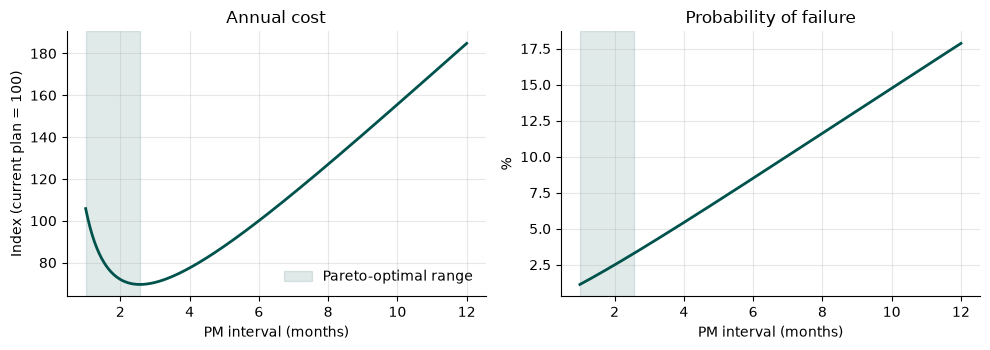

In [4]:
# Both objectives across the full 1 to 12 month range
x = np.linspace(*pm.BOUNDS, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

ax1.plot(x, model.cost_index(x), color=TEAL, lw=2)
# Shade the Pareto-optimal range on both curves
ax1.axvspan(x_exact.min(), x_exact.max(), color=TEAL, alpha=0.12, label="Pareto-optimal range")
ax1.set(title="Annual cost", xlabel="PM interval (months)", ylabel="Index (current plan = 100)")
ax1.legend(frameon=False)

ax2.plot(x, model.failure_prob(x) * 100, color=TEAL, lw=2)
ax2.axvspan(x_exact.min(), x_exact.max(), color=TEAL, alpha=0.12)
ax2.set(title="Probability of failure", xlabel="PM interval (months)", ylabel="%")

fig.tight_layout()
plt.show()

## Recommended plan
The recommended plan is the lowest-cost Pareto-optimal plan.

In [5]:
# Current plan (6 months) and the cheapest plan, which is always on the front
# (both are also used by the Pareto figure below)
current = plans.set_index("interval_months").loc[pm.CURRENT_PM_INTERVAL]
selected = plans.loc[plans["annual_cost_index"].idxmin()]

# Negative change in cost is a saving; positive change in reliability is an improvement
pm.compare_with_current(model).round(2)

,Current (6M),Recommended (2M 2W),Change
"Annual cost (index, current plan = 100)",100.0,69.58,-30.42
Reliability over interval (%),91.5,96.80,5.30
